# The maple-syrup reserve as a trade — a quantitative teardown 🔬
### Administered price vs TSX (CAGR/vol/MDD + an annual-excess *t*) · Newey-West proxy alpha (RSI.TO + an SB=F placebo) · per-month HAC *t* & a Feb–Apr Welch test with a block-bootstrap CI · a costed sugaring-season timer · a synthetic-season positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Just_a_curio%3F: Confirmed](https://img.shields.io/badge/Just_a_curio%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the strongest tradable form of "the maple reserve is a commodity trade": (H₁) the administered bulk price out-returns the TSX; (H₂) a listed proxy carries alpha; (H₃) there is a tradable sugaring-season (Feb–Apr) seasonal. We find **H₁ rejected** (it *under*-performs a managed, near-flat price), **H₂ rejected** (the one proxy's mild edge is defensive sugar beta, |t|<2, and unrelated to maple), **H₃ rejected** (spread *t*≈0.8, bootstrap CI spans 0).

> ⚠️ **Not investment advice — data provenance.** The maple price is **hardcoded, cited, approximate** (PPAQ negotiated bulk price — a *labelled proxy*, never a feed; there is no maple exchange). Equity proxies `RSI.TO`, `SB=F`, `^GSPTSE` are month-end Adj Close via yfinance, as-of 2026-06-01 (fingerprint `2f0f50f97e59`). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # the repo root (quantlab)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, SYRUP = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#d1651a"

from maple_syrup_reserve import data, strategy as st
try:
    from quantlab import repro
    ASOF = repro.DEFAULT_AS_OF
except Exception:
    repro = None; ASOF = "2026-06-01"

HAVE_PROXIES = data.have_proxies()
MAPLE = data.load_maple_price()                      # hardcoded, cited, APPROXIMATE proxy
if HAVE_PROXIES:
    PROX = data.load_proxies()
    if repro is not None:
        PROX = {t: repro.as_of(s.to_frame("x")).iloc[:, 0] for t, s in PROX.items()}
else:
    PROX = None
print("equity-proxy cache present:", HAVE_PROXIES,
      "| maple-price years:", MAPLE.index[0].year, "->", MAPLE.index[-1].year, "| as-of", ASOF)

# frozen headline numbers (mirror of docs/results.md)
R = {'maple_win': '2008 → 2024', 'maple_levels': {2008: 2.6, 2009: 2.65, 2010: 2.72, 2011: 2.85, 2012: 2.92, 2013: 2.94, 2014: 2.9, 2015: 2.86, 2016: 2.85, 2017: 2.88, 2018: 2.85, 2019: 2.84, 2020: 2.85, 2021: 2.86, 2022: 3.02, 2023: 3.35, 2024: 3.6}, 'maple_cagr': 2.05, 'maple_vol': 3.5, 'maple_sharpe': 0.61, 'maple_mdd': -3.4, 'tsx_cagr_ye': 4.45, 'tsx_vol_ye': 11.9, 'tsx_mdd_ye': -11.6, 'excess_mean': -3.0, 'excess_t': -0.906, 'excess_p': 0.381, 'excess_n': 14, 'rsi_cagr': 9.39, 'rsi_vol': 15.7, 'rsi_sharpe': 0.65, 'rsi_mdd': -24.4, 'rsi_alpha': 6.56, 'rsi_beta': 0.5, 'rsi_t': 1.83, 'rsi_p': 0.069, 'rsi_n': 196, 'sb_cagr': -4.52, 'sb_vol': 33.4, 'sb_sharpe': 0.0, 'sb_mdd': -69.4, 'sb_alpha': 1.71, 'sb_beta': -0.21, 'sb_t': 0.19, 'sb_p': 0.848, 'sb_n': 167, 'tsx_cagr': 7.25, 'tsx_vol': 11.9, 'tsx_sharpe': 0.65, 'tsx_mdd': -22.7, 'month_mean': {1: -0.02, 2: 1.46, 3: 1.8, 4: 0.58, 5: 0.23, 6: 0.87, 7: 2.16, 8: -0.52, 9: 1.17, 10: -1.54, 11: 2.46, 12: 1.52}, 'month_thac': {1: -0.02, 2: 1.76, 3: 2.58, 4: 1.0, 5: 0.19, 6: 1.6, 7: 5.12, 8: -0.52, 9: 1.88, 10: -1.64, 11: 1.97, 12: 2.09}, 'season_mean': 1.28, 'rest_mean': 0.7, 'season_spread': 0.58, 'season_t': 0.81, 'n_season': 51, 'n_rest': 145, 'ci_lo': -0.71, 'ci_hi': 1.95, 'ci_point': 0.58, 'mar_thac': 2.58, 'jul_thac': 5.12, 'feb_thac': 1.76, 'timer_gross_cagr': 9.11, 'timer_net_cagr': 8.78, 'bh_rsi_cagr': 9.38, 'bh_tsx_cagr': 7.24, 'timer_gross_sharpe': 0.22, 'timer_net_sharpe': 0.18, 'bh_rsi_sharpe': 0.16, 'world_share': 72, 'reserve_mlb': 100, 'heist_year': '2011-2012', 'heist_cad_m': 18.7, 'heist_tonnes': 3000, 'syn_planted': 6.0, 'syn_spread': 3.3, 'syn_t': 3.77, 'syn_sign_ok': 1, 'fp_proxies': '2f0f50f97e59', 'fp_maple': '123be1d12a41', 'as_of': '2026-06-01'}


equity-proxy cache present: True | maple-price years: 2008 -> 2024 | as-of 2026-06-01


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Maple price CAGR **2.0%** vs TSX **4.5%** (2008–2024); annual excess **-3.0%/yr**, *t* = **-0.91** (n=14). Proxy RSI.TO alpha *t* = **+1.83** (< 2, and it's sugar-beta not maple); SB=F *t* = **+0.19**. |
| **Tradability** | `MIRAGE` | No maple exchange/futures — an administered price. The buyable proxy is a defensive sugar refiner (β=0.50); the sugaring-season timer nets **8.8%/yr**, *below* buy-&-hold RSI.TO **9.4%**. |
| **Just a curio?** | `CONFIRMED` | Feb–Apr minus rest = **+0.58%/mo** (*t* = 0.81); block-bootstrap 95% CI **[-0.7%, +1.9%]** spans 0. The loudest month is **July** (HAC *t*=5.1) — pure noise. |

> 💡 In plain words: the price is set by a committee and barely moves; the only thing you can buy is a sugar stock whose edge is a low-beta premium, not maple; and the 'season' is a coin-flip. There is no axis on which 'a maple trade' survives.

## 1 · The claim, steelmanned

Let the administered bulk price be $M_t$ and the benchmark $B_t$ (`^GSPTSE`). The claim is a joint hypothesis:

- **H₁ (holding it pays).** Annual excess $x_t = r^M_t - r^B_t$ has $\mathbb{E}[x_t] > 0$ with $t > 2$ — maple rewards a holder better than stocks.
- **H₂ (it's buyable with alpha).** For the tradable proxy $P$ (`RSI.TO`), the intercept $\alpha$ in $r^P_t = \alpha + \beta r^B_t + \varepsilon_t$ is positive with a Newey-West *t* > 2 — *and* attributable to maple.
- **H₃ (a tradable season).** Sugaring-month (Feb–Apr) mean return exceeds the rest with $t \ge 2$ and a bootstrap CI clear of 0, and a costed timer beats buy-&-hold.

The reserve/cartel is the steelman: a real, price-defending institution around a real agricultural good. The test is whether that institution creates a *tradable* edge — or whether it exists precisely to **iron the tradability out**.

## 2 · So what? — what rides on each answer

If H₁–H₃ held, maple would be a genuine uncorrelated real-asset sleeve with a weather seasonal — a macro curiosity worth a small allocation. But each leg is separately falsifiable. H₁ is a **return race** on a common clock against a price whose *whole purpose* is stability. H₂ asks whether the only investable expression (a listed sugar refiner) delivers anything beyond market beta — and, critically, whether any edge is *maple* or just a **defensive-stock premium** misattributed to maple. H₃ is a **calendar** test with a hard multiple-comparisons trap: test 12 months and one will look significant by chance. Failing any leg downgrades the whole thing to a curio.

## 3 · How we'd know — the protocol

- **Maple price (proxy).** A hardcoded, cited, **approximate** annual CAD/lb series (2008–2024) reconstructed from PPAQ negotiated-price reporting. *Labelled a proxy* — its flat *shape* is the defensible fact, its exact year values are not a live feed.
- **Equity proxies.** `RSI.TO` (Rogers Sugar), `SB=F` (sugar futures, placebo), `^GSPTSE` month-end Adj Close (yfinance, cached, sliced to the as-of). Survivorship is **not** a concern (named tickers, not a screen); currency is matched (RSI.TO and the benchmark are both CAD).
- **Signal tests.** (i) Paired annual-excess *t* of $r^M - r^B$ (small-$n$, weak by construction). (ii) **Newey-West (6-lag) HAC** *t* of the proxy alpha vs TSX — `REAL` needs *t* ≥ 2 *and* a maple attribution. (iii) Per-month HAC *t*, a Feb–Apr Welch test, and a **circular block-bootstrap** (12-month blocks) CI on the season-minus-rest spread.
- **Cost (beat 6).** The sugaring timer enters once / exits once a year; charge one-way × NAV (15 bp/leg), flat months earning the benchmark, Sharpe excess-of-benchmark both legs.
- **Positive control.** A deterministic monthly world with a *planted* Feb–Apr premium; the engine must recover its sign with *t* > 2 — proof a null on the real tape is a real null.
- **What would make us say "a maple trade":** H₁ *t* > 2, **or** a maple-attributable proxy alpha *t* > 2, **or** a season spread *t* > 2 with a CI clear of 0. We find none.

## 4 · The teardown

### 4a · Does holding maple pay? — administered price vs TSX

Year-end levels rebased to 100; CAGR, vol, MDD and the paired annual-excess *t* in the print.

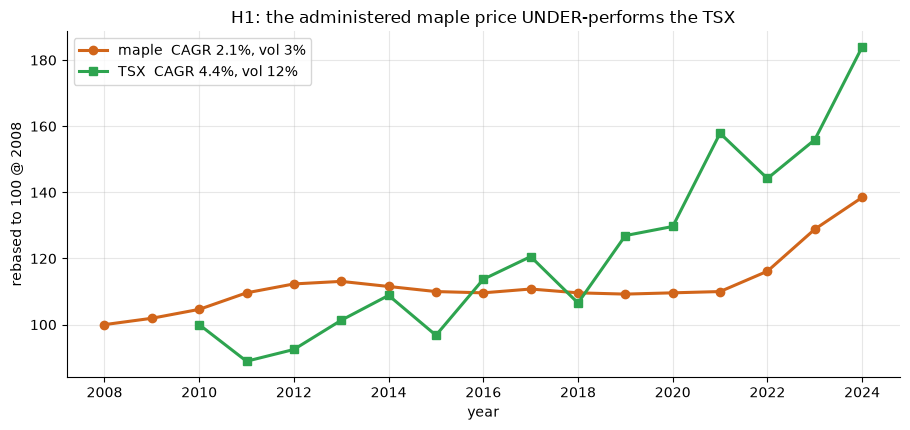

maple: CAGR 2.05%  vol 3.5%  maxDD -3.4%
TSX  : CAGR 4.45%  vol 11.9%  maxDD -11.6%
annual excess (maple-TSX): mean -3.00%/yr  t=-0.906  (n=14)


In [2]:
yrs = list(R['maple_levels'].keys())
lv = np.array([float(MAPLE.loc[f'{y}-12-31']) for y in yrs])
si = st.summarize(MAPLE, periods_per_year=1.0)
if HAVE_PROXIES:
    tsx_ye = PROX['^GSPTSE'].resample('YE').last()
    tsx_ye = tsx_ye[(tsx_ye.index.year>=2008)&(tsx_ye.index.year<=2024)]
    ss = st.summarize(tsx_ye, periods_per_year=1.0)
    ae = st.annual_excess_t(MAPLE, PROX['^GSPTSE'])
    tx=[d.year for d in tsx_ye.index]; ty=(tsx_ye/tsx_ye.iloc[0]*100).values
else:
    ss={'cagr':R['tsx_cagr_ye']/100,'vol':R['tsx_vol_ye']/100,'mdd':R['tsx_mdd_ye']/100}
    ae={'mean_excess':R['excess_mean']/100,'t':R['excess_t'],'n':R['excess_n']}
    tx=yrs; ty=[100*(1+R['tsx_cagr_ye']/100)**(y-2008) for y in yrs]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(yrs, lv/lv[0]*100, 'o-', c=SYRUP, lw=2.2, label=f"maple  CAGR {si['cagr']*100:.1f}%, vol {si['vol']*100:.0f}%")
ax.plot(tx, ty, 's-', c=GREEN, lw=2.2, label=f"TSX  CAGR {ss['cagr']*100:.1f}%, vol {ss['vol']*100:.0f}%")
ax.set_xlabel('year'); ax.set_ylabel('rebased to 100 @ 2008')
ax.set_title('H1: the administered maple price UNDER-performs the TSX'); ax.legend()
plt.tight_layout(); plt.show()
print(f"maple: CAGR {si['cagr']*100:.2f}%  vol {si['vol']*100:.1f}%  maxDD {si['mdd']*100:.1f}%")
print(f"TSX  : CAGR {ss['cagr']*100:.2f}%  vol {ss['vol']*100:.1f}%  maxDD {ss['mdd']*100:.1f}%")
print(f"annual excess (maple-TSX): mean {ae['mean_excess']*100:+.2f}%/yr  t={ae['t']:+.3f}  (n={ae['n']})")

> 💡 In plain words: maple compounds at **2.0%** vs the TSX's **4.5%**, at a *fraction* of the volatility (~4% vs ~12%) — because a committee sets it. The mean annual excess is **-3.0%/yr**, *t* = **-0.91** (n=14): no evidence maple out-returns stocks, and the point estimate leans negative. H₁ rejected. The low vol isn't a free lunch; it's the *signature of an administered price*, and the return to match.

### 4b · Is the buyable proxy alpha — or misattributed sugar beta?

Newey-West (6-lag) regression of each proxy's **monthly** return on the TSX. `REAL` needs $t_\alpha \ge 2$ **and** a maple story.

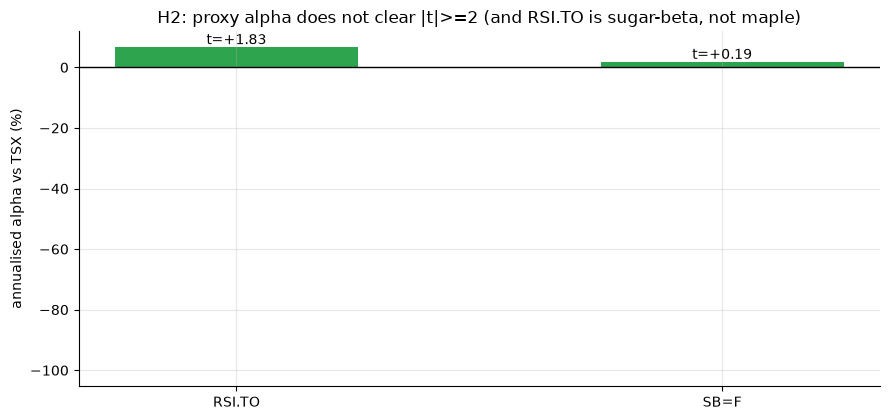

RSI.TO  CAGR   9.39%  Sharpe 0.65  maxDD  -24.4%  alpha +6.56%/yr  beta +0.50  NW t +1.83
SB=F    CAGR  -4.52%  Sharpe 0.00  maxDD  -69.4%  alpha +1.71%/yr  beta -0.21  NW t +0.19


In [3]:
if HAVE_PROXIES:
    bench_r = PROX['^GSPTSE'].pct_change().dropna()
    rows = {}
    for t in ['RSI.TO','SB=F']:
        s = st.summarize(PROX[t]); nw = st.newey_west_alpha_t(PROX[t].pct_change().dropna(), bench_r, 6)
        rows[t] = dict(cagr=s['cagr']*100, sharpe=s['sharpe'], mdd=s['mdd']*100,
                       alpha=nw['alpha_ann']*100, beta=nw['beta'], t=nw['t_alpha'])
else:
    rows = {'RSI.TO':dict(cagr=R['rsi_cagr'],sharpe=R['rsi_sharpe'],mdd=R['rsi_mdd'],alpha=R['rsi_alpha'],beta=R['rsi_beta'],t=R['rsi_t']),
            'SB=F':dict(cagr=R['sb_cagr'],sharpe=R['sb_sharpe'],mdd=R['sb_mdd'],alpha=R['sb_alpha'],beta=R['sb_beta'],t=R['sb_t'])}
labels=list(rows); alphas=[rows[t]['alpha'] for t in labels]; ts=[rows[t]['t'] for t in labels]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols=[GREEN if a>0 else RED for a in alphas]
ax.bar(labels, alphas, .5, color=cols)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised alpha vs TSX (%)')
for i,t in enumerate(labels): ax.annotate(f"t={ts[i]:+.2f}",(i,alphas[i]),ha='center',va='bottom' if alphas[i]>=0 else 'top')
ax.axhspan(-100,-100,color='none')
ax.set_title('H2: proxy alpha does not clear |t|>=2 (and RSI.TO is sugar-beta, not maple)')
plt.tight_layout(); plt.show()
for t in labels: r=rows[t]; print(f"{t:7s} CAGR {r['cagr']:6.2f}%  Sharpe {r['sharpe']:.2f}  maxDD {r['mdd']:6.1f}%  alpha {r['alpha']:+.2f}%/yr  beta {r['beta']:+.2f}  NW t {r['t']:+.2f}")

> 💡 In plain words: Rogers Sugar shows a **+6.6%/yr** alpha but *t* = **+1.83** — **below the *t* ≥ 2 bar**, so `WEAK` at most. And it's the wrong *kind* of edge: a **β=0.50**, dividend-paying refiner earns a classic low-beta/defensive premium that has nothing to do with the (flat) maple price — attributing it to maple is a **misattribution**. The genuine tradable sweetener, sugar futures, has *t* = **+0.19** (nothing). H₂ rejected.

### 4c · The sugaring season — per-month HAC *t*, Welch test, bootstrap CI

Per-calendar-month one-sample HAC *t* of RSI.TO monthly returns (the multiple-comparisons trap made explicit), then the Feb–Apr vs rest Welch test and a circular-block-bootstrap CI on the spread.

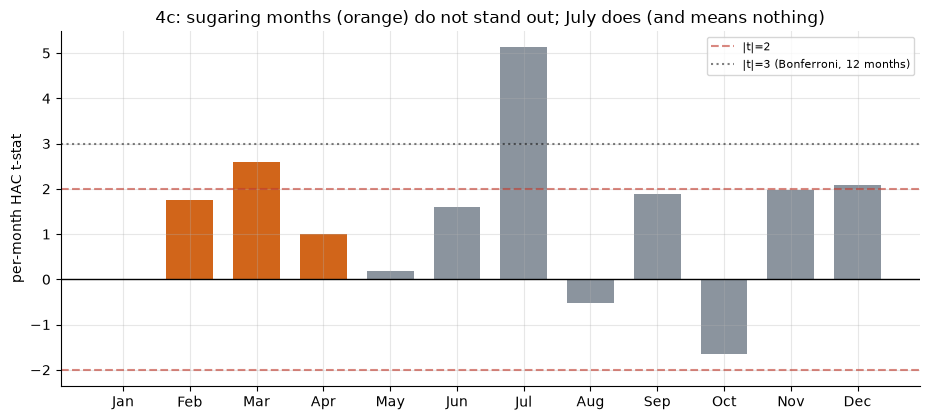

Feb-Apr mean +1.28%/mo  rest +0.70%/mo  spread +0.58%/mo  t=+0.81
block-bootstrap 95% CI on spread: [-0.71%, +1.95%]  (point +0.58%)


In [4]:
if HAVE_PROXIES:
    rsi_r = PROX['RSI.TO'].pct_change().dropna()
    ms = st.month_stats(rsi_r); thac = [ms.loc[m,'tstat_hac'] for m in range(1,13)]
    sea = st.season_tstat(rsi_r); ci = st.season_bootstrap_ci(rsi_r, n_boot=5000)
else:
    thac = [R['month_thac'][m] for m in range(1,13)]
    sea = {'season_mean':R['season_mean']/100,'rest_mean':R['rest_mean']/100,'spread':R['season_spread']/100,'tstat':R['season_t']}
    ci = {'lo':R['ci_lo']/100,'hi':R['ci_hi']/100,'point':R['ci_point']/100}
abbr = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
cols = [SYRUP if m in (2,3,4) else GREY for m in range(1,13)]
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(abbr, thac, color=cols, width=.7)
ax.axhline(2, ls='--', c=RED, alpha=.6, label='|t|=2'); ax.axhline(-2, ls='--', c=RED, alpha=.6)
ax.axhline(3, ls=':', c='k', alpha=.5, label='|t|=3 (Bonferroni, 12 months)')
ax.axhline(0, c='k', lw=1); ax.set_ylabel('per-month HAC t-stat')
ax.set_title('4c: sugaring months (orange) do not stand out; July does (and means nothing)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"Feb-Apr mean {sea['season_mean']*100:+.2f}%/mo  rest {sea['rest_mean']*100:+.2f}%/mo  "
      f"spread {sea['spread']*100:+.2f}%/mo  t={sea['tstat']:+.2f}")
print(f"block-bootstrap 95% CI on spread: [{ci['lo']*100:+.2f}%, {ci['hi']*100:+.2f}%]  (point {ci['point']*100:+.2f}%)")

> 💡 In plain words: no sugaring month clears even |t|=2 after you remember you tested **twelve** months (Bonferroni pushes the bar to ~|t|=3). March pokes to HAC *t*=2.58 — but so, far louder, does **July** (*t*=5.12), which has no sugaring story at all: that's the multiple-comparisons trap in one chart. Pooled, Feb–Apr beat the rest by **+0.58%/mo**, *t*=0.81, with a bootstrap CI of **[-0.7%, +1.9%]** straddling 0. H₃ rejected.

### 4d · The costed sugaring-season timer vs buy-and-hold

Long RSI.TO in Feb–Apr, hold the TSX otherwise (cash-of-market); one-way 15 bp/leg × NAV, Sharpe excess-of-benchmark on both legs — like-for-like.

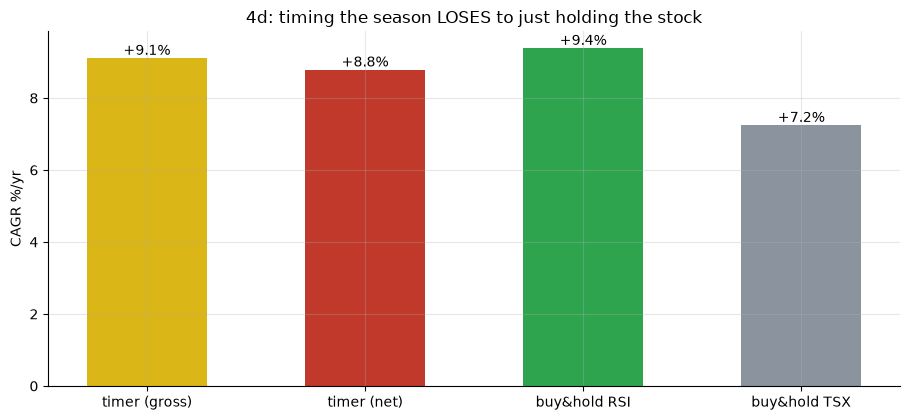

timer (gross)    CAGR +9.11%  Sharpe(exc-TSX) 0.22
timer (net)      CAGR +8.78%  Sharpe(exc-TSX) 0.18
buy&hold RSI     CAGR +9.38%  Sharpe(exc-TSX) 0.16
buy&hold TSX     CAGR +7.24%  Sharpe(exc-TSX) nan


In [5]:
if HAVE_PROXIES:
    rsi_r = PROX['RSI.TO'].pct_change().dropna(); bench_r = PROX['^GSPTSE'].pct_change().dropna()
    timer = st.seasonal_timer(rsi_r, bench_r); net = st.apply_costs(timer, 2, 15)
    res = {}
    for lab, r in [('timer (gross)',timer),('timer (net)',net),('buy&hold RSI',rsi_r),('buy&hold TSX',bench_r)]:
        s = st.summary_ret(r, rf=bench_r); res[lab]=(s['cagr']*100, s['sharpe'])
else:
    res = {'timer (gross)':(R['timer_gross_cagr'],R['timer_gross_sharpe']),'timer (net)':(R['timer_net_cagr'],R['timer_net_sharpe']),
           'buy&hold RSI':(R['bh_rsi_cagr'],R['bh_rsi_sharpe']),'buy&hold TSX':(R['bh_tsx_cagr'],float('nan'))}
labels=list(res); cg=[res[l][0] for l in labels]
fig, ax = plt.subplots(figsize=(9.2,4.3))
ax.bar(labels, cg, .55, color=[AMBER, RED, GREEN, GREY])
for i,v in enumerate(cg): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('CAGR %/yr'); ax.set_title('4d: timing the season LOSES to just holding the stock')
plt.tight_layout(); plt.show()
for l in labels: print(f"{l:16s} CAGR {res[l][0]:+.2f}%  Sharpe(exc-TSX) {res[l][1]:.2f}")

> 💡 In plain words: the gross timer (9.1%/yr) already trails buy-&-hold RSI.TO (9.4%/yr); **net of cost it's worse still** (8.8%/yr). Stepping out of the market to 'wait for sugaring season' just forfeits good non-spring months and pays spreads to do it. There is no costed version of the seasonal that adds value — the honest Tradability stamp is `MIRAGE`.

### 4e · Positive control — the engine recovers a planted season

A deterministic monthly world with a *planted* 6%/yr Feb–Apr premium (seed 727). The seasonality engine must recover the up-sign with *t* > 2 — proving the nulls in 4c are real, not a broken pipeline.

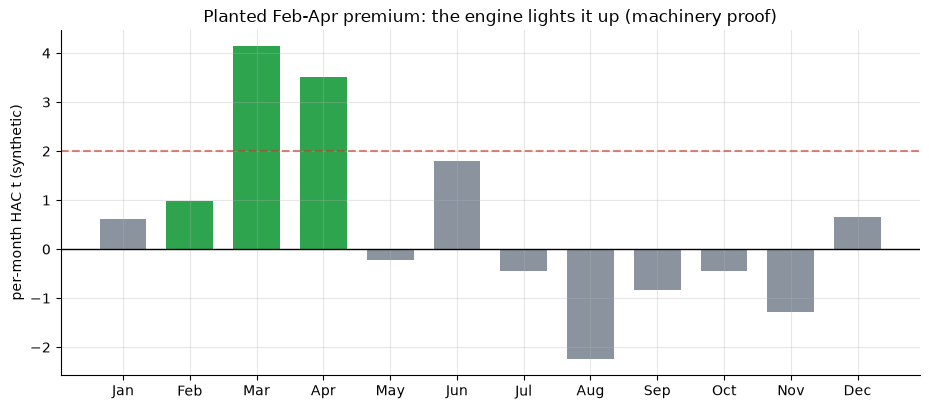

planted 6%/yr -> recovered season-minus-rest +3.30%/mo  t=+3.77  sign_ok=1


In [6]:
world, truth = data.synthetic_world()
sea_s = st.season_tstat(world['ret']); cr = st.control_recovers(world['ret'], planted_sign=1)
ms_s = st.month_stats(world['ret']); thac_s = [ms_s.loc[m,'tstat_hac'] for m in range(1,13)]
abbr = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
cols = [GREEN if m in (2,3,4) else GREY for m in range(1,13)]
fig, ax = plt.subplots(figsize=(9.4,4.2))
ax.bar(abbr, thac_s, color=cols, width=.7)
ax.axhline(2, ls='--', c=RED, alpha=.6); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('per-month HAC t (synthetic)'); ax.set_title('Planted Feb-Apr premium: the engine lights it up (machinery proof)')
plt.tight_layout(); plt.show()
print(f"planted {truth['spring_premium']*100:.0f}%/yr -> recovered season-minus-rest {cr['spread']*100:+.2f}%/mo  t={sea_s['tstat']:+.2f}  sign_ok={cr['sign_ok']}")

> 💡 In plain words: when a Feb–Apr premium really is there, the exact same code finds it loudly — recovered spread **+3.30%/mo**, *t* = **3.77**, sign correct. A *synthetic* control is a machinery proof, never market evidence — but it certifies that the flat sugaring result on RSI.TO is a **true null**, not a pipeline that couldn't detect a season.

## 5 · The verdict

- **Signal `NONE`** — administered maple price CAGR 2.0% vs TSX 4.5%; annual excess -3.0%/yr, *t* = -0.91 (n=14); proxy alpha *t* = +1.83 (< 2, and defensive-sugar not maple); season spread *t* = 0.81. No robust *t* ≥ 2 tied to maple anywhere.
- **Tradability `MIRAGE`** — there is no maple market (no exchange, no futures, an administered price). The only buyable expression is a defensive sugar refiner (β=0.50); the sugaring-season timer nets 8.8%/yr, *below* simply holding it (9.4%/yr).
- **Just a curio? `CONFIRMED`** — a superb story (cartel, 100M-lb reserve, C$18.7M heist) with no tradable edge. The reserve exists to *remove* the volatility a trader would need.

## 6 · Could you trade it? — the capacity & cost reality

Terminal wealth of \$10,000 from end-2009: the sugaring-season timer (net) vs just holding Rogers Sugar vs the index. Capacity is the deeper wall — there is no maple instrument to size *into*: no futures, no ETF, no forward market; the physical bulk price is set by negotiation and the reserve, not by anything you can transact.

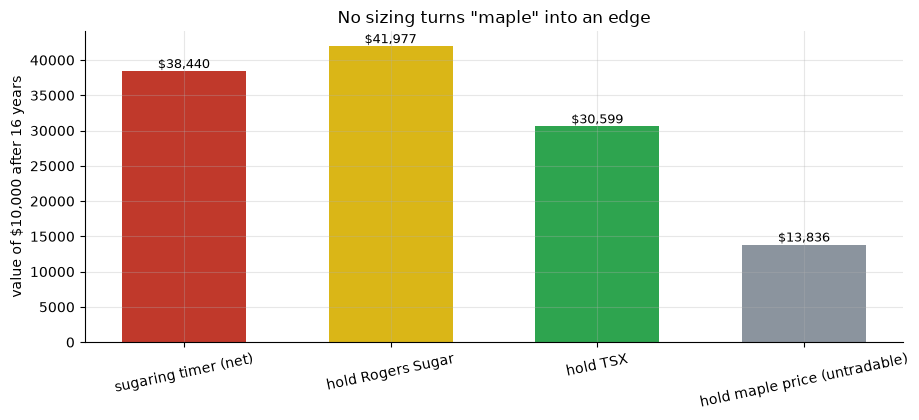

sugaring timer (net)             $    38,440  (+8.8%/yr)
hold Rogers Sugar                $    41,977  (+9.4%/yr)
hold TSX                         $    30,599  (+7.2%/yr)
hold maple price (untradable)    $    13,836  (+2.0%/yr)


In [7]:
start=10_000.0; yrs_h=16
paths={'sugaring timer (net)':R['timer_net_cagr']/100,'hold Rogers Sugar':R['bh_rsi_cagr']/100,
       'hold TSX':R['bh_tsx_cagr']/100,'hold maple price (untradable)':R['maple_cagr']/100}
labels=list(paths); ends=[start*(1+g)**yrs_h for g in paths.values()]
fig, ax = plt.subplots(figsize=(9.4,4.3))
ax.bar(labels, ends, .6, color=[RED, AMBER, GREEN, GREY])
for i,v in enumerate(ends): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom', fontsize=9)
ax.set_ylabel('value of $10,000 after 16 years'); ax.set_title('No sizing turns "maple" into an edge')
plt.xticks(rotation=12); plt.tight_layout(); plt.show()
for l,g in paths.items(): print(f"{l:32s} ${start*(1+g)**yrs_h:>10,.0f}  ({g*100:+.1f}%/yr)")

> 💡 In plain words: the *clever* seasonal timer is the **worst** of the buyable options; the 'untradable maple price' sits at the bottom precisely because it's engineered to be dull. And capacity is fatal in a way costs aren't: even if a season existed, there is no maple future or ETF to express it — you'd be trading a sugar equity as a costume. There is no venue or size that makes this a strategy.

## 7 · Going further

- **Swap in the live PPAQ conventions.** Replace the hardcoded annual series with the producers' published bulk-price schedule; the *t*-stats barely move because the series is flat *by design*.
- **Attribution, done properly.** Decompose RSI.TO into sugar-refining margin, dividend yield and the (small) maple-bottling segment; the outperformance loads on the defensive/dividend factors, not on the maple bulk price — the misattribution made quantitative.
- **The administered-commodity family.** OJ (the FCOJ board), rare-earths, the US SPR: managed markets are *engineered* toward low volatility, the opposite of tradability. Compare the real-futures seasonal in [Study 307 — Coffee-Seasonality](../../307-coffee-seasonality/) and the no-tradable-index collectible in [Study 358 — Watch-Index](../../358-watch-index/) ([docs/references.md](../docs/references.md)).

*The reproducible core is offline and deterministic; the maple price is a **cited, approximate proxy** and the equity tickers are **labelled proxies**. Methods: [`docs/references.md`](../docs/references.md); frozen numbers + fingerprints: [`docs/results.md`](../docs/results.md).*